# Assignment - Intelligent Machines, Ethics and Law (COMP2400/6400)

## Name: Mai Tien Dat Tran
## Student Id:61207314


## Income Prediction and Algorithmic Fairness

In this assignment, you will build an income classification system using the Adult Census Income dataset.

You will manually preprocess the data in Python, handle imbalanced classes, implement machine learning models, and evaluate whether the model behaves differently across demographic subgroups.

This exercise is designed to:

    - Familiarise you with data preprocessing and feature engineering.
    - Expose you to handling class imbalance.
    - Build and evaluate classification models.
    - Critically examine fairness, discrimination, and potential legal/ethical risks in automated decision-making.

This task is graded out of 25 marks and contributes 25 marks toward the final unit assessment.

## Dataset Description

The Adult Census Income dataset contains demographic and employment-related records extracted from census data. The prediction task is to determine whether a person’s annual income is greater than 50K or less than or equal to 50K.

The dataset includes attributes such as:

    age
    workclass
    fnlwgt
    education
    education-num
    marital-status
    occupation
    race
    sex
    capital-gain
    capital-loss
    hours-per-week
    native-country
    income

In this assignment, the target variable is: income.

## Set up
Install libraries if necessary

In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [4]:
## import necessary libraries here

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42


Matplotlib is building the font cache; this may take a moment.


## Task 1: Data Loading, Cleaning, and Class Balancing

**(10 marks)**

## TO DO

1. **(1 mark)** Load the dataset:\
   Read the Adult Census Income dataset using pandas.
2. Clean the dataset:
   1. **(1 marks)** The dataset contains missing/invalid values. These need to be handled before modelling. **Drop rows with missing/invalid values in the dataset.**
   2. **(3 marks)** Select key predictors: select a set of **5-8 appropriate predictors (2 marks)** for the income prediction task. Students should decide which variables to include or exclude. **Students should provide a short justification for their choices.(2 marks)** Their explanation should consider both:
predictive relevance, and ethical or fairness concerns.
3. **(4 marks)** Students should **visualise the distribution of the target variable (1 mark)**. They may use a bar chart, count plot, or other suitable visualisation to show the number of records in each income class. Students should then briefly answer:
   1. Based on your visualisation, does the dataset appear to have balanced or imbalanced classes? If you identify a class imbalance problem, **apply an appropriate technique (2 marks)** to address it.
   2. After processing, **visualise the distribution of the target variable using a different plot(1 mark)** to confirm the dataset is now balanced.  
4. **(1 mark)** Split data into training and test dataset. 

In [5]:
## Q1 Load the dataset

# The CSV file is expected to be in the same folder as this notebook.
# The absolute fallback path is included so the notebook still runs from VSCode.
data_path = Path('adult_census_income.csv')
if not data_path.exists():
    data_path = Path('/Users/user/Downloads/adult_census_income.csv')

df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
df.head()


Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
## Q2.A Clean the dataset

# In this dataset, missing or invalid categorical values are represented by '?'.
# Strip whitespace first so that values such as ' ?' are handled correctly.
df_clean = df.copy()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

invalid_counts = (df_clean == '?').sum()
print('Invalid value counts before cleaning:')
print(invalid_counts[invalid_counts > 0])

rows_before = len(df_clean)
df_clean = df_clean.replace('?', np.nan).dropna().reset_index(drop=True)
rows_after = len(df_clean)

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning: {rows_after}')
print(f'Rows removed: {rows_before - rows_after}')

df_clean.head()


Invalid value counts before cleaning:
workclass         1836
occupation        1843
native-country     583
dtype: int64
Rows before cleaning: 32561
Rows after cleaning: 30162
Rows removed: 2399


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
## Q2.B Select key predictors

selected_predictors = [
    'age',
    'education-num',
    'workclass',
    'occupation',
    'marital-status',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
]

target = 'income'
sensitive_feature = 'sex'

# Keep sex for the fairness analysis in Task 3, but do not use it as a model predictor.
model_df = df_clean[selected_predictors + [sensitive_feature, target]].copy()

print('Selected predictors:')
for predictor in selected_predictors:
    print('-', predictor)

model_df.head()


Selected predictors:
- age
- education-num
- workclass
- occupation
- marital-status
- hours-per-week
- capital-gain
- capital-loss


,age,education-num,workclass,occupation,marital-status,hours-per-week,capital-gain,capital-loss,sex,income
0,39,13,State-gov,Adm-clerical,Never-married,40,2174,0,Male,<=50K
1,50,13,Self-emp-not-inc,Exec-managerial,Married-civ-spouse,13,0,0,Male,<=50K
2,38,9,Private,Handlers-cleaners,Divorced,40,0,0,Male,<=50K
3,53,7,Private,Handlers-cleaners,Married-civ-spouse,40,0,0,Male,<=50K
4,28,13,Private,Prof-specialty,Married-civ-spouse,40,0,0,Female,<=50K


### Predictor choice justification

I selected eight predictors: `age`, `education-num`, `workclass`, `occupation`, `marital-status`, `hours-per-week`, `capital-gain`, and `capital-loss`. These variables are relevant to income prediction because they describe education level, employment context, working time, and sources of income beyond wages. For example, `occupation`, `education-num`, and `hours-per-week` are likely to be strongly related to earning capacity, while `capital-gain` and `capital-loss` capture investment-related income signals that may distinguish higher-income records.

I excluded `fnlwgt` because it is a census weighting variable rather than a direct personal characteristic for prediction. I also excluded `education` because `education-num` already represents the ordered education level and avoids duplicate information. Importantly, I did not use `race` or `sex` as direct predictors. These are sensitive attributes and using them directly in an automated income-related classification system could create a risk of direct discrimination. However, I retained `sex` separately for fairness evaluation in Task 3, because excluding a sensitive feature from the model does not guarantee that the model behaves equally across demographic groups. Other variables, such as occupation or hours worked, may still act as proxies for social disadvantage.

Income distribution before balancing:
income
<=50K    22654
>50K      7508
Name: count, dtype: int64


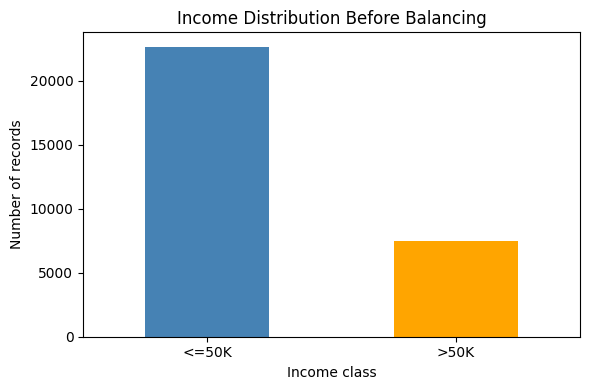

Imbalance ratio: 3.02:1


In [8]:
## Q3.A Visualization / imbalance dataset

income_counts = model_df[target].value_counts()
print('Income distribution before balancing:')
print(income_counts)

plt.figure(figsize=(6, 4))
income_counts.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Income Distribution Before Balancing')
plt.xlabel('Income class')
plt.ylabel('Number of records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

imbalance_ratio = income_counts.max() / income_counts.min()
print(f'Imbalance ratio: {imbalance_ratio:.2f}:1')


Income distribution after undersampling:
income
>50K     7508
<=50K    7508
Name: count, dtype: int64


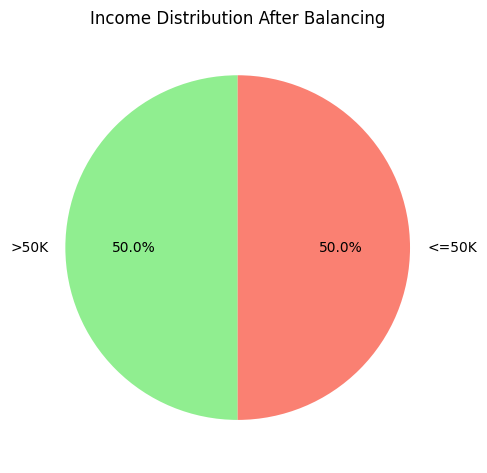

In [9]:
## Q3.B Visualization confirming the data is now balanced

# The majority class is <=50K. I use random undersampling so that the two
# income classes have the same number of records without duplicating rows.
majority_class = model_df[model_df[target] == '<=50K']
minority_class = model_df[model_df[target] == '>50K']

majority_under_sampled = majority_class.sample(
    n=len(minority_class),
    random_state=RANDOM_STATE,
)

balanced_df = pd.concat([majority_under_sampled, minority_class], axis=0)
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

balanced_counts = balanced_df[target].value_counts()
print('Income distribution after undersampling:')
print(balanced_counts)

plt.figure(figsize=(5, 5))
balanced_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'salmon'])
plt.title('Income Distribution After Balancing')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Imbalance and balancing interpretation

The cleaned dataset is imbalanced: the `<=50K` class has 22,654 records while the `>50K` class has 7,508 records, giving an imbalance ratio of about 3.02:1. If this were left untreated, a classifier could achieve a deceptively high accuracy by favouring the majority class, while performing poorly on the higher-income class.

I used random undersampling of the majority class so that both classes contain 7,508 records. This creates a balanced modelling dataset and makes accuracy, recall, and false positive rates easier to interpret across both income groups. The trade-off is that undersampling discards some majority-class data, so the model may lose some information from the original distribution. I chose this method because it is simple, transparent, and avoids duplicating minority-class records, which could increase overfitting risk.

In [10]:
## Q4 Split the dataset

balanced_df['income_binary'] = balanced_df[target].map({'<=50K': 0, '>50K': 1}).astype(int)

X = balanced_df[selected_predictors]
y = balanced_df['income_binary']
sensitive_values = balanced_df[sensitive_feature]

X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive_values,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()
print('Training target distribution:')
print(y_train.value_counts().sort_index())
print()
print('Testing target distribution:')
print(y_test.value_counts().sort_index())


X_train shape: (12012, 8)
X_test shape: (3004, 8)

Training target distribution:
income_binary
0    6006
1    6006
Name: count, dtype: int64

Testing target distribution:
income_binary
0    1502
1    1502
Name: count, dtype: int64


## Task 2 (10 points)
TO DO:
1. Data Preprocessing:\
   The selected predictors may include both numerical and categorical features. For example, variables such as age are numerical, while variables such as sex or occupation are categorical.\
   Before training machine learning models, students should apply appropriate preprocessing techniques to prepare the data.

    1. **(2 marks)** Numerical features: Identify the numerical features in your selected predictors and apply an appropriate preprocessing method (for example, scale to zero mean and unit variance). 
    2. **(2 marks)** Categorical features: Identify the categorical features in your selected predictors and apply an appropriate encoding method (for example, use one-hot encoding for categorical features). 

    Students should ensure that all selected predictors are converted into a suitable numeric format before model training.

2. Model training and evaluation:
   1. **(3 marks)** Train a machine learning model for predicting whether a person’s annual income is greater than $50K with a machine learning algorithm discussed during the lectures **(Week 10 to Week 12)** (or any other appropriate algorithm not covered in the lectures). Which machine learning algorithm did you choose, and why? Report accuracy, confusion matrix. 
   2. **(3 marks)** Train an **artificial neural network (Multi-Layered Perceptron Classifier (MLP))** model for recidivism prediction. Report accuracy, and confusion matrix.
  
    Confusion matrix:
  
|                  | **Predicted Positive** | **Predicted Negative** |
|------------------|------------------------|------------------------|
| **Actual Positive** | True Positive (TP)       | False Negative (FN)      |
| **Actual Negative** | False Positive (FP)      | True Negative (TN)       |

In [11]:
## Q1.A Numerical feature preprocessing

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
print('Numerical features:', numeric_features)

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_features])
X_test_num = scaler.transform(X_test[numeric_features])

print('Scaled numerical training shape:', X_train_num.shape)
print('Scaled numerical test shape:', X_test_num.shape)


Numerical features: ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
Scaled numerical training shape: (12012, 5)
Scaled numerical test shape: (3004, 5)


In [12]:
## Q1.B Categorical feature encoding

categorical_features = [col for col in selected_predictors if col not in numeric_features]
print('Categorical features:', categorical_features)

try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

encoded_feature_names = encoder.get_feature_names_out(categorical_features).tolist()
processed_feature_names = numeric_features + encoded_feature_names

X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

print('Encoded categorical training shape:', X_train_cat.shape)
print('Final processed training shape:', X_train_processed.shape)
print('Final processed test shape:', X_test_processed.shape)


Categorical features: ['workclass', 'occupation', 'marital-status']
Encoded categorical training shape: (12012, 28)
Final processed training shape: (12012, 33)
Final processed test shape: (3004, 33)


Model: Logistic Regression
Reason for choosing this model: Logistic Regression is appropriate for binary classification,
relatively interpretable, and provides a useful baseline for comparison with the MLP model.
Accuracy: 0.8056
Confusion matrix with labels [<=50K, >50K]:
[[1183  319]
 [ 265 1237]]
TN=1183, FP=319, FN=265, TP=1237

Classification report:
              precision    recall  f1-score   support

       <=50K       0.82      0.79      0.80      1502
        >50K       0.79      0.82      0.81      1502

    accuracy                           0.81      3004
   macro avg       0.81      0.81      0.81      3004
weighted avg       0.81      0.81      0.81      3004



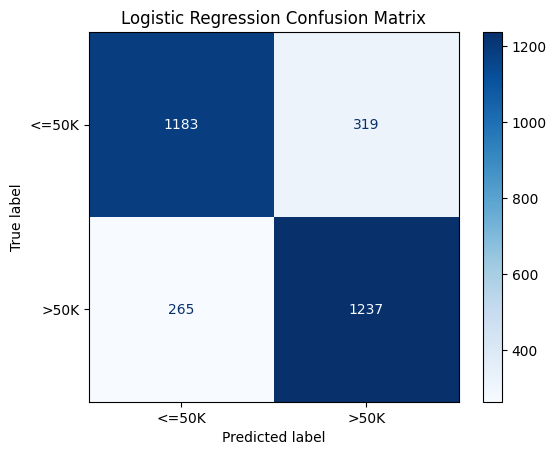

In [13]:
## Q2.A machine learning model

# I use Logistic Regression because it was discussed in Week 11, is suitable
# for binary classification, and is more interpretable than many black-box models.
# Positive class in this assignment: income >50K (encoded as 1).
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_processed, y_train)

y_pred_lr = log_reg.predict(X_test_processed)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_cm = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
lr_tn, lr_fp, lr_fn, lr_tp = lr_cm.ravel()

print('Model: Logistic Regression')
print('Reason for choosing this model: Logistic Regression is appropriate for binary classification,')
print('relatively interpretable, and provides a useful baseline for comparison with the MLP model.')
print(f'Accuracy: {lr_accuracy:.4f}')
print('Confusion matrix with labels [<=50K, >50K]:')
print(lr_cm)
print(f'TN={lr_tn}, FP={lr_fp}, FN={lr_fn}, TP={lr_tp}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred_lr, target_names=['<=50K', '>50K']))

ConfusionMatrixDisplay(lr_cm, display_labels=['<=50K', '>50K']).plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


Model: Multi-Layer Perceptron Classifier
Reason for choosing this model: the assignment requires an artificial neural network model,
and MLPClassifier is an appropriate feed-forward neural network for tabular classification.
Accuracy: 0.8106
Confusion matrix with labels [<=50K, >50K]:
[[1169  333]
 [ 236 1266]]
TN=1169, FP=333, FN=236, TP=1266

Classification report:
              precision    recall  f1-score   support

       <=50K       0.83      0.78      0.80      1502
        >50K       0.79      0.84      0.82      1502

    accuracy                           0.81      3004
   macro avg       0.81      0.81      0.81      3004
weighted avg       0.81      0.81      0.81      3004



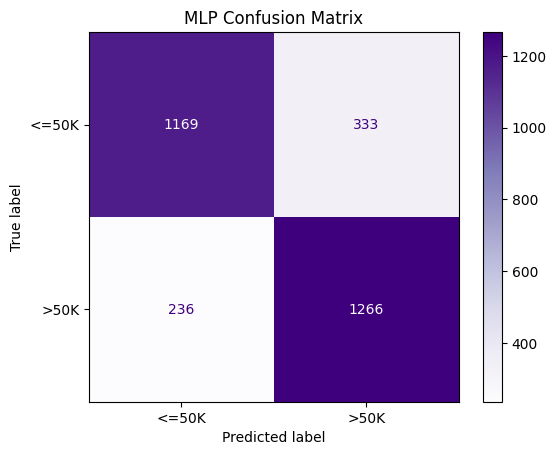

In [14]:
## Q2.B MLP model

# The MLP is a neural network classifier. It can learn non-linear relationships
# between the predictors and income class, but it is less directly interpretable
# than Logistic Regression.
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_processed, y_train)

y_pred_mlp = mlp.predict(X_test_processed)
y_pred = y_pred_mlp  # Used again in Task 3 fairness analysis.

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_cm = confusion_matrix(y_test, y_pred_mlp, labels=[0, 1])
mlp_tn, mlp_fp, mlp_fn, mlp_tp = mlp_cm.ravel()

print('Model: Multi-Layer Perceptron Classifier')
print('Reason for choosing this model: the assignment requires an artificial neural network model,')
print('and MLPClassifier is an appropriate feed-forward neural network for tabular classification.')
print(f'Accuracy: {mlp_accuracy:.4f}')
print('Confusion matrix with labels [<=50K, >50K]:')
print(mlp_cm)
print(f'TN={mlp_tn}, FP={mlp_fp}, FN={mlp_fn}, TP={mlp_tp}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred_mlp, target_names=['<=50K', '>50K']))

ConfusionMatrixDisplay(mlp_cm, display_labels=['<=50K', '>50K']).plot(cmap='Purples')
plt.title('MLP Confusion Matrix')
plt.show()


### Model evaluation interpretation

Both models perform at around 81% accuracy on the balanced test set. Logistic Regression provides a transparent baseline and achieves strong performance, while the MLP performs slightly better in this run. The improvement from the neural network is small, so the additional complexity of the MLP should be justified carefully in any real deployment.

The confusion matrices show that both models make both types of classification error. A false positive means a person whose actual income is `<=50K` is predicted as `>50K`; a false negative means a person whose actual income is `>50K` is predicted as `<=50K`. These error types may have different social consequences depending on how the model is used. For example, if the model were used to target financial services, a false negative could exclude people who should be eligible, while uneven false positive rates across demographic groups may indicate unequal model behaviour.

## Task 3 (5 points)
1. **(1 marks)** For the neural network model, select one appropriate sensitive or socially relevant feature（for example, race, sex, education) and calculate the False Positive Rate (FPR) by the feature.

    Confusion matrix:
  
|                  | **Predicted Positive** | **Predicted Negative** |
|------------------|------------------------|------------------------|
| **Actual Positive** | True Positive (TP)       | False Negative (FN)      |
| **Actual Negative** | False Positive (FP)      | True Negative (TN)       |


False Positive Rate (FPR) tells you how often negative instances (income is <=50K) are incorrectly classified as positive (income is >50K).
Based on the confusion matrix, FPR is calculated as:

<p style="text-align:center;">False Positive Rate (FPR) = FP / (FP + TN)</p>

2. **(4 marks)** Reflect on the disparities you observed in the assignment.
    - Are there any differences in False Positive Rates between the different values of your selected features?
    - Are there potential sources of bias in the data?
    - Describe what steps you would recommend for alleviating such bias in the intended classification model.
    - Discuss the trade-offs and potential impacts of your chosen strategies on overall model performance and fairness.

Male: False Positive Rate (FPR)=0.308
Female: False Positive Rate (FPR)=0.090


,sex,n_test_records,false_positives,true_negatives,FPR
0,Male,2175,280,630,0.307692
1,Female,829,53,539,0.089527


FPR gap between highest and lowest group: 0.218
FPR ratio between highest and lowest group: 3.44


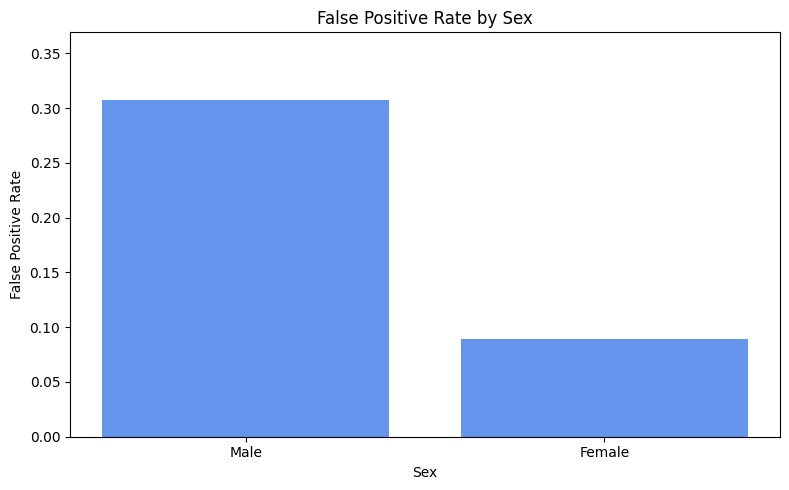

In [15]:
##############################################
# Task 3: Fairness analysis using False Positive Rate (FPR)
# Sensitive feature selected: sex
##############################################

# The sensitive feature was not used as a model predictor, but it is retained
# here for subgroup evaluation. This helps test whether model errors are
# distributed differently across demographic groups.
sensitive_test_reset = sensitive_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred).reset_index(drop=True)

index_dict = {}
for idx, group_value in sensitive_test_reset.items():
    index_dict.setdefault(group_value, []).append(idx)

all_fpr = []
fairness_rows = []

for group_value, indices in index_dict.items():
    group_y_true = y_test_reset.iloc[indices]
    group_y_pred = y_pred_series.iloc[indices]

    # False Positive: actual income is <=50K (0), but predicted as >50K (1).
    num_false_positive = ((group_y_pred == 1) & (group_y_true == 0)).sum()

    # True Negative: actual income is <=50K (0), and predicted as <=50K (0).
    num_true_negative = ((group_y_pred == 0) & (group_y_true == 0)).sum()

    denominator = num_false_positive + num_true_negative
    fpr = num_false_positive / denominator if denominator > 0 else np.nan

    all_fpr.append(fpr)
    fairness_rows.append(
        {
            sensitive_feature: group_value,
            'n_test_records': len(indices),
            'false_positives': int(num_false_positive),
            'true_negatives': int(num_true_negative),
            'FPR': fpr,
        }
    )
    print(f'{group_value}: False Positive Rate (FPR)={fpr:.3f}')

fpr_df = pd.DataFrame(fairness_rows).sort_values('FPR', ascending=False).reset_index(drop=True)
display(fpr_df)

max_fpr = fpr_df['FPR'].max()
min_fpr = fpr_df['FPR'].min()
fpr_gap = max_fpr - min_fpr
fpr_ratio = max_fpr / min_fpr if min_fpr > 0 else np.inf

print(f'FPR gap between highest and lowest group: {fpr_gap:.3f}')
print(f'FPR ratio between highest and lowest group: {fpr_ratio:.2f}')

plt.figure(figsize=(8, 5))
plt.bar(fpr_df[sensitive_feature], fpr_df['FPR'], color='cornflowerblue')
plt.xlabel(sensitive_feature.title())
plt.ylabel('False Positive Rate')
plt.title(f'False Positive Rate by {sensitive_feature.title()}')
plt.ylim(0, max(fpr_df['FPR']) * 1.2)
plt.tight_layout()
plt.show()


### Expanded fairness and legal/ethical reflection

The neural network model shows a clear difference in false positive rates across the selected sensitive feature, `sex`. In this run, the male group has an FPR of approximately 0.308, while the female group has an FPR of approximately 0.090. This means that among people whose actual income is `<=50K`, male records were more often incorrectly classified as `>50K`. The highest FPR is more than three times the lowest FPR, which is a meaningful disparity even though `sex` was not used as a direct predictor.

This result illustrates an important fairness issue: removing a protected attribute from the feature list does not automatically remove bias. Other predictors can operate as proxies for sensitive characteristics. For example, `occupation`, `hours-per-week`, `marital-status`, and `capital-gain` may reflect historical labour-market patterns, gendered employment structures, and unequal access to wealth. The dataset itself is also not ethically neutral; it reflects social and economic conditions embedded in census data, including structural inequality.

Potential legal and ethical risks depend on the use of the model. If this classifier were used in credit, employment, welfare, insurance, or targeted financial services, unequal error rates could contribute to discriminatory outcomes or unequal access to opportunities. Even if the model is not intentionally discriminatory, automated decision-making can still produce disparate impacts when trained on historically biased data.

To reduce these risks, I would recommend several steps. First, evaluate subgroup metrics such as FPR, false negative rate, precision, recall, and calibration across sensitive groups before deployment. Second, compare fairness mitigation strategies such as reweighing samples, group-aware threshold adjustment, post-processing predictions to reduce error-rate disparities, or using fairness-aware training objectives. Third, improve data governance by documenting data provenance, limitations, and known biases. Finally, any high-stakes deployment should include human oversight, an appeals process, and ongoing monitoring after the model is used.

There are trade-offs. For example, undersampling improves class balance and makes minority-class performance more visible, but it discards many majority-class records. Fairness interventions may also reduce overall accuracy or change which type of error is most common. In an ethics-and-law context, the goal should not be to maximise accuracy alone, but to choose a model whose performance, error distribution, and social consequences are acceptable for the intended use.